In [1]:
# Import required libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score


In [3]:
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [4]:
df['target'] = iris.target

print("First 5 Rows of Dataset:")
print(df.head())

First 5 Rows of Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [6]:
# Split dataset into Features and Target

X = df.iloc[:, :-1]   # Features
y = df.iloc[:, -1]    # Target

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [7]:
# Apply Naive Bayes Algorithm
model = GaussianNB()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

In [8]:

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

error_rate = 1 - accuracy

print("\nAccuracy :", accuracy)
print("Error Rate :", error_rate)
print("Precision :", precision)
print("Recall :", recall)


Accuracy : 0.9777777777777777
Error Rate : 0.022222222222222254
Precision : 0.9761904761904763
Recall : 0.9743589743589745


In [10]:
print("\nTP, FP, TN, FN for each class:\n")

for i in range(len(cm)):
    
    TP = cm[i, i]
    
    FP = cm[:, i].sum() - TP
    
    FN = cm[i, :].sum() - TP
    
    TN = cm.sum() - (TP + FP + FN)
    
    print(f"Class {i}:")
    print("TP =", TP)
    print("FP =", FP)
    print("FN =", FN)
    print("TN =", TN)
    print("----------------------")
    


TP, FP, TN, FN for each class:

Class 0:
TP = 19
FP = 0
FN = 0
TN = 26
----------------------
Class 1:
TP = 12
FP = 0
FN = 1
TN = 32
----------------------
Class 2:
TP = 13
FP = 1
FN = 0
TN = 31
----------------------


In [16]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)


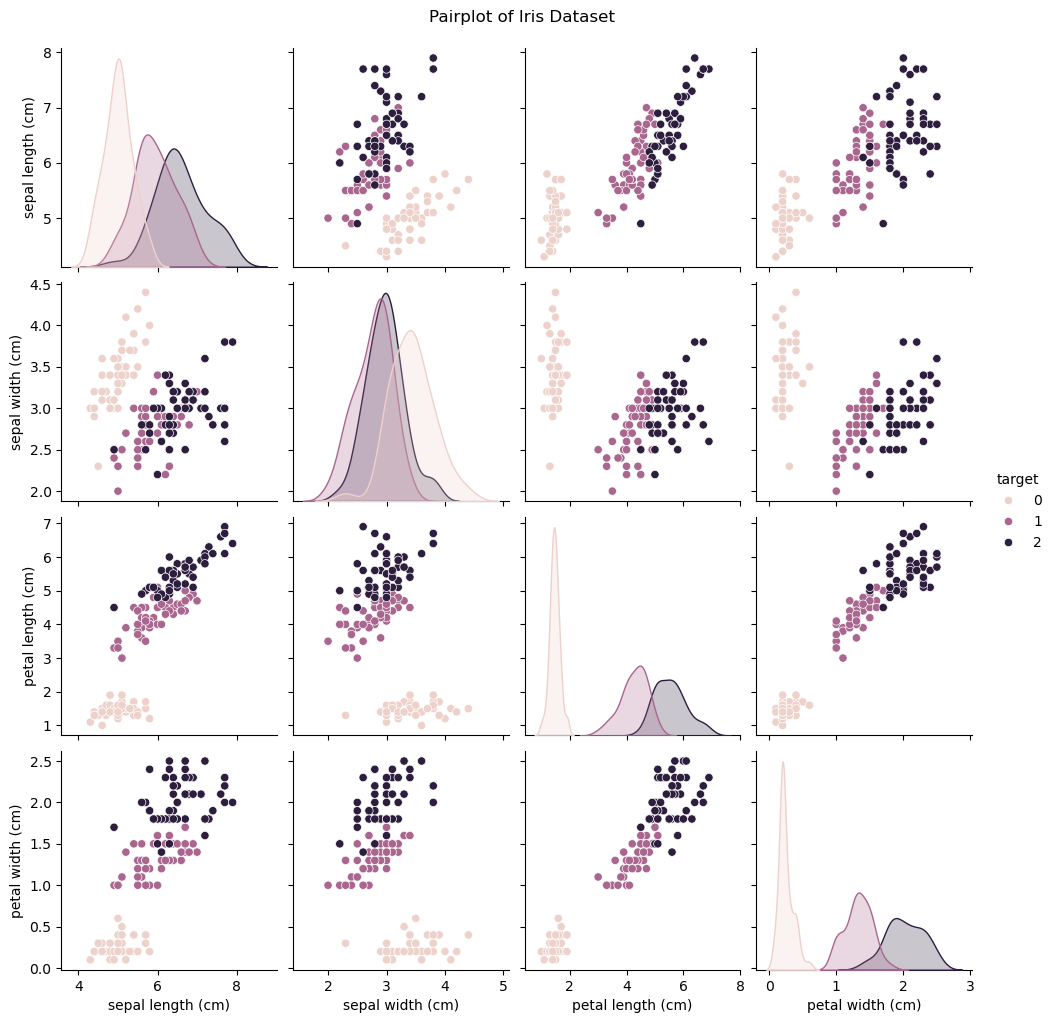

In [17]:
sns.pairplot(df, hue='target')
plt.suptitle("Pairplot of Iris Dataset", y=1.02)
plt.show()